<a href="https://colab.research.google.com/github/ShifaZahra123/ML_INTERNSHIP/blob/main/Brain_Tumor_Detection_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Tumor Detection.zip to Tumor Detection.zip


In [2]:
import zipfile
import os

with zipfile.ZipFile("Tumor Detection.zip", 'r') as zip_ref:
    zip_ref.extractall("Tumor Detection")

In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.9 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo11n.pt")

# Train the model
train_results = model.train(
    data="/content/Tumor Detection/data.yaml",  # path to dataset YAML
    epochs=20,  # number of training epochs
    imgsz=640,  # training image size
    device=0,  # device to run on, i.e. device=0 or device=0,1,2,3 or device=cpu, train model on gpu not on cpu
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Tumor Detection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,

In [7]:
from google.colab import files
uploaded = files.upload()

Saving test_images.zip to test_images.zip


In [8]:
import zipfile
import os

with zipfile.ZipFile("test_images.zip", 'r') as zip_ref:
    zip_ref.extractall("test_images")


image 1/1 /content/test_images/test_images/meningioma_3.jpg: 640x640 1 meningioma, 10.5ms
Speed: 2.3ms preprocess, 10.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


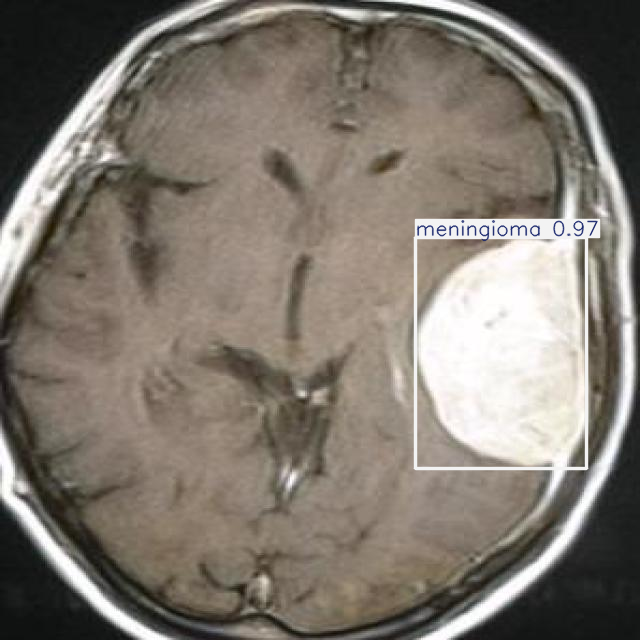

In [12]:
from ultralytics import YOLO

# Load a model
model = YOLO("/content/runs/detect/train/weights/best.pt")
# Output of YOLO11 (Bounding Box) now becomes the input of SAM2 Model for INTANCE SEGMENTATION
# Perform object detection on an image
results = model("/content/test_images/test_images/meningioma_3.jpg", save=True)
results[0].show()

In [14]:
from ultralytics import YOLO

# Load a model
model = YOLO("/content/runs/detect/train/weights/best.pt")
# Output of YOLO11 (Bounding Box) now becomes the input of SAM2 Model for INTANCE SEGMENTATION
# Perform object detection on an image
results = model("/content/test_images/test_images", save=True)


image 1/4 /content/test_images/test_images/glioma_2.jpg: 640x640 1 glioma, 7.8ms
image 2/4 /content/test_images/test_images/meningioma_3.jpg: 640x640 1 meningioma, 7.8ms
image 3/4 /content/test_images/test_images/no_tumor_1.jpg: 640x640 1 NO_tumor, 8.0ms
image 4/4 /content/test_images/test_images/pituitary_5.jpg: 640x640 1 pituitary, 7.8ms
Speed: 1.5ms preprocess, 7.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2


In [16]:
from ultralytics import YOLO
# For Box Coordinates
# Load a model
model = YOLO("runs/detect/train/weights/best.pt")  # pretrained YOLO11n model

# Run batched inference on a list of images
results = model("test_images/test_images/glioma_2.jpg")  # return a list of Results objects

# Process results list
for result in results:
    boxes = result.boxes  # Boxes object for bounding box outputs
    print(boxes)


image 1/1 /content/test_images/test_images/glioma_2.jpg: 640x640 1 glioma, 9.9ms
Speed: 1.9ms preprocess, 9.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([1.], device='cuda:0')
conf: tensor([0.8195], device='cuda:0')
data: tensor([[274.4644, 420.9302, 314.1246, 444.3291,   0.8195,   1.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (640, 640)
shape: torch.Size([1, 6])
xywh: tensor([[294.2945, 432.6297,  39.6602,  23.3989]], device='cuda:0')
xywhn: tensor([[0.4598, 0.6760, 0.0620, 0.0366]], device='cuda:0')
xyxy: tensor([[274.4644, 420.9302, 314.1246, 444.3291]], device='cuda:0')
xyxyn: tensor([[0.4289, 0.6577, 0.4908, 0.6943]], device='cuda:0')


In [18]:
from ultralytics import YOLO
from ultralytics import SAM

# Load the YOLO model
yolo_model = YOLO("runs/detect/train/weights/best.pt")  # pretrained YOLO model

# Run batched inference on a list of images
results = yolo_model("/content/test_images/test_images/meningioma_3.jpg")  # return a list of Results objects

# Load the SAM model for intance segmentation
sam_model = SAM("sam2_b.pt") # SAM Model is of Meta but it also integrate into ultalytics package, so need no to install it seperately
#sam2_b "b for base model, one of the category of sam 2 model"
for result in results:
     class_ids = result.boxes.cls.int().tolist()
     if len(class_ids):
         boxes = result.boxes.xyxy  # Boxes object for bbox outputs
         sam_results = sam_model(result.orig_img, bboxes=boxes, verbose=False, save=True, device=0)


image 1/1 /content/test_images/test_images/meningioma_3.jpg: 640x640 1 meningioma, 11.1ms
Speed: 2.0ms preprocess, 11.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict
